In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/eeshawn/flickr30k/captions.txt
/kaggle/input/datasets/eeshawn/flickr30k/flickr30k_images/2715746315.jpg
/kaggle/input/datasets/eeshawn/flickr30k/flickr30k_images/3463034205.jpg
/kaggle/input/datasets/eeshawn/flickr30k/flickr30k_images/268704620.jpg
/kaggle/input/datasets/eeshawn/flickr30k/flickr30k_images/2673564214.jpg
/kaggle/input/datasets/eeshawn/flickr30k/flickr30k_images/7535037918.jpg
/kaggle/input/datasets/eeshawn/flickr30k/flickr30k_images/4912369161.jpg
/kaggle/input/datasets/eeshawn/flickr30k/flickr30k_images/4828071602.jpg
/kaggle/input/datasets/eeshawn/flickr30k/flickr30k_images/6802728196.jpg
/kaggle/input/datasets/eeshawn/flickr30k/flickr30k_images/3346289227.jpg
/kaggle/input/datasets/eeshawn/flickr30k/flickr30k_images/3217056901.jpg
/kaggle/input/datasets/eeshawn/flickr30k/flickr30k_images/272471327.jpg
/kaggle/input/datasets/eeshawn/flickr30k/flickr30k_images/4717261252.jpg
/kaggle/input/datasets/eeshawn/flickr30k/flickr30k_images/4763916790.jpg

In [56]:
import os
import re
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import layers, Model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D,
    Dense, Embedding, TextVectorization
)

In [3]:
captions_df = pd.read_csv("/kaggle/input/datasets/eeshawn/flickr30k/captions.txt")

captions_df.head()


,image_name,comment_number,comment
0,1000092795.jpg,0,Two young guys with shaggy hair look at their ...
1,1000092795.jpg,1,Two young White males are outside near many b...
2,1000092795.jpg,2,Two men in green shirts are standing in a yard .
3,1000092795.jpg,3,A man in a blue shirt standing in a garden .
4,1000092795.jpg,4,Two friends enjoy time spent together .


In [4]:
def clean_caption(text):
    text = text.lower()

    # Remove punctuation
    text = re.sub(r"[^a-z0-9\s]", "", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return "[START] " + text + " [END]"


In [5]:
captions_df["caption"] = captions_df["comment"].apply(clean_caption)

print(captions_df.head())


       image_name  comment_number  \
0  1000092795.jpg               0   
1  1000092795.jpg               1   
2  1000092795.jpg               2   
3  1000092795.jpg               3   
4  1000092795.jpg               4   

                                             comment  \
0  Two young guys with shaggy hair look at their ...   
1  Two young  White males are outside near many b...   
2   Two men in green shirts are standing in a yard .   
3       A man in a blue shirt standing in a garden .   
4            Two friends enjoy time spent together .   

                                             caption  
0  [START] two young guys with shaggy hair look a...  
1  [START] two young white males are outside near...  
2  [START] two men in green shirts are standing i...  
3  [START] a man in a blue shirt standing in a ga...  
4  [START] two friends enjoy time spent together ...  


In [6]:
unique_images = captions_df["image_name"].unique()

np.random.seed(42)
np.random.shuffle(unique_images)

split = int(len(unique_images) * 0.8)

train_images = unique_images[:split]
val_images = unique_images[split:]

train_df = captions_df[
    captions_df["image_name"].isin(train_images)
].reset_index(drop=True)

val_df = captions_df[
    captions_df["image_name"].isin(val_images)
].reset_index(drop=True)

print("Training captions:", len(train_df))
print("Validation captions:", len(val_df))


Training captions: 127130
Validation captions: 31785


In [7]:
MAX_TOKENS = 10000
MAX_LENGTH = 30

vectorizer = TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=MAX_LENGTH,
    standardize=None
)

vectorizer.adapt(captions_df["caption"].values)

sample = vectorizer(
    tf.constant(["[START] a dog is running [END]"])
)

print(sample)

I0000 00:00:1789289490.151699      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


tf.Tensor(
[[ 3  2 34 10 75  4  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0]], shape=(1, 30), dtype=int64)


In [8]:
vectorizer = TextVectorization(
        max_tokens=MAX_TOKENS,
        output_mode="int",
        output_sequence_length=MAX_LENGTH,
        standardize=None
    )


vectorizer.adapt(
      captions_df["caption"].values
    )

IMAGE_SIZE = 256


In [9]:
IMAGE_SIZE = 256

def load_image(image_path):
    image = tf.io.read_file(image_path)

    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    image = tf.image.resize(
        image,
        (IMAGE_SIZE, IMAGE_SIZE)
    )

    image = tf.cast(image, tf.float32) / 255.0

    return image


In [10]:
IMAGE_DIR = "/kaggle/input/datasets/eeshawn/flickr30k/flickr30k_images"

def get_image_path(filename):
    return os.path.join(
        IMAGE_DIR,
        filename
    )


In [11]:
train_paths = train_df["image_name"].apply(
    get_image_path
).values

train_captions = train_df["caption"].values

val_paths = val_df["image_name"].apply(
    get_image_path
).values

val_captions = val_df["caption"].values



In [12]:
BATCH_SIZE = 16

train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_captions)
)

train_dataset = train_dataset.shuffle(10000)


In [13]:
def preprocess_pair(image_path, caption):

    image = load_image(image_path)

    caption = vectorizer(caption)

    return image, caption


In [14]:
train_dataset = train_dataset.map(
    preprocess_pair,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_dataset = train_dataset.batch(
    BATCH_SIZE
)

train_dataset = train_dataset.prefetch(
    tf.data.AUTOTUNE
)


In [15]:
val_dataset = tf.data.Dataset.from_tensor_slices(
    (val_paths, val_captions)
)

val_dataset = val_dataset.map(
    preprocess_pair,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_dataset = val_dataset.batch(BATCH_SIZE)
val_dataset = val_dataset.prefetch(tf.data.AUTOTUNE)


In [16]:
class ImageEncoder(Model):

    def __init__(self, embedding_dim=512):

        super().__init__()

        self.conv1 = Conv2D(
            64,
            3,
            padding="same",
            activation="selu"
        )

        self.pool1 = MaxPooling2D(2)

        self.conv2 = Conv2D(
            128,
            3,
            padding="same",
            activation="selu"
        )

        self.pool2 = MaxPooling2D(2)

        self.conv3 = Conv2D(
            256,
            3,
            padding="same",
            activation="selu"
        )

        self.pool3 = MaxPooling2D(2)

        self.conv4 = Conv2D(
            512,
            3,
            padding="same",
            activation="selu"
        )

        self.global_pool = GlobalAveragePooling2D()

        self.projection = Dense(
            embedding_dim
        )

    def call(self, images):

        x = self.conv1(images)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.pool2(x)

        x = self.conv3(x)
        x = self.pool3(x)

        x = self.conv4(x)

        x = self.global_pool(x)

        x = self.projection(x)

        return x


In [17]:
image_encoder = ImageEncoder(
    embedding_dim=512
)


In [18]:
class TextEncoder(Model):

    def __init__(
        self,
        vocab_size,
        embedding_dim=512,
        max_length=32,
        num_heads=8
    ):

        super().__init__()

        self.token_embedding = Embedding(
            vocab_size,
            embedding_dim
        )

        self.position_embedding = Embedding(
            max_length,
            embedding_dim
        )

        self.attention = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embedding_dim // num_heads
        )

        self.norm1 = layers.LayerNormalization()

        self.dense1 = Dense(
            embedding_dim * 4,
            activation="gelu"
        )

        self.dense2 = Dense(
            embedding_dim
        )

        self.norm2 = layers.LayerNormalization()

        self.projection = Dense(
            embedding_dim
        )

    def call(self, tokens):

        positions = tf.range(
            start=0,
            limit=tf.shape(tokens)[1]
        )

        token_embeddings = self.token_embedding(
            tokens
        )

        position_embeddings = self.position_embedding(
            positions
        )

        x = token_embeddings + position_embeddings

        attention_output = self.attention(
            x,
            x
        )

        x = self.norm1(
            x + attention_output
        )

        ff = self.dense1(x)
        ff = self.dense2(ff)

        x = self.norm2(
            x + ff
        )

        # Mean pooling
        x = tf.reduce_mean(
            x,
            axis=1
        )

        x = self.projection(x)

        return x


In [19]:
VOCAB_SIZE = len(vectorizer.get_vocabulary())

text_encoder = TextEncoder(
    vocab_size=VOCAB_SIZE,
    embedding_dim=512,
    max_length=MAX_LENGTH
)


In [20]:
def normalize_embeddings(x):

    return tf.math.l2_normalize(
        x,
        axis=1
    )


In [21]:
class CLIP(Model):

    def __init__(
        self,
        image_encoder,
        text_encoder
    ):

        super().__init__()

        self.image_encoder = image_encoder
        self.text_encoder = text_encoder

        # Learnable temperature
        self.logit_scale = tf.Variable(
            np.log(1 / 0.07),
            dtype=tf.float32,
            trainable=True,
            name="logit_scale"
        )

    def call(self, images, captions):

        image_embeddings = self.image_encoder(
            images
        )

        text_embeddings = self.text_encoder(
            captions
        )

        image_embeddings = normalize_embeddings(
            image_embeddings
        )

        text_embeddings = normalize_embeddings(
            text_embeddings
        )

        logit_scale = tf.exp(
            self.logit_scale
        )

        logits = logit_scale * tf.matmul(
            image_embeddings,
            text_embeddings,
            transpose_b=True
        )

        return logits


In [22]:
clip_model = CLIP(
    image_encoder,
    text_encoder
)


In [23]:
def clip_loss(logits):

    batch_size = tf.shape(logits)[0]

    labels = tf.range(
        batch_size
    )

    image_to_text_loss = tf.keras.losses.sparse_categorical_crossentropy(
        labels,
        logits,
        from_logits=True
    )

    text_to_image_loss = tf.keras.losses.sparse_categorical_crossentropy(
        labels,
        tf.transpose(logits),
        from_logits=True
    )

    loss = (
        image_to_text_loss +
        text_to_image_loss
    ) / 2.0

    return tf.reduce_mean(loss)


In [24]:
optimizer = tf.keras.optimizers.Adam(
    learning_rate=1e-4
)


In [25]:
@tf.function
def train_step(images, captions):

    with tf.GradientTape() as tape:

        logits = clip_model(
            images,
            captions
        )

        loss = clip_loss(
            logits
        )

    gradients = tape.gradient(
        loss,
        clip_model.trainable_variables
    )

    optimizer.apply_gradients(
        zip(
            gradients,
            clip_model.trainable_variables
        )
    )

    return loss


In [36]:
EPOCHS = 5

with tf.device("GPU:0"):
    for epoch in range(EPOCHS):
        total_loss = 0.0
        num_batches = 0
        
        print("Training on dataset: /kaggle/input/datasets/eeshawn/flickr30k/")
        
        for images, captions in train_dataset:
            loss = train_step(images, captions)
            total_loss += loss
            num_batches += 1
    
        avg_loss = total_loss / num_batches
        print(f"Epoch {epoch + 1}/{EPOCHS} - Loss: {avg_loss:.4f}")


Training on dataset: /kaggle/input/datasets/eeshawn/flickr30k/
Epoch 1/5 - Loss: 0.9627
Training on dataset: /kaggle/input/datasets/eeshawn/flickr30k/
Epoch 2/5 - Loss: 0.8638
Training on dataset: /kaggle/input/datasets/eeshawn/flickr30k/
Epoch 3/5 - Loss: 0.7702
Training on dataset: /kaggle/input/datasets/eeshawn/flickr30k/
Epoch 4/5 - Loss: 0.6774
Training on dataset: /kaggle/input/datasets/eeshawn/flickr30k/
Epoch 5/5 - Loss: 0.5921


In [51]:
images, captions = next(iter(train_dataset))
print("image : \n",images[0])
print("caption : \n", captions[0])

image : 
 tf.Tensor(
[[[0.2972527  0.30208573 0.28224486]
  [0.2988235  0.29973498 0.26811835]
  [0.27329198 0.2751149  0.23428991]
  ...
  [0.63760287 0.5409449  0.29979655]
  [0.66291463 0.5428063  0.32110098]
  [0.6468401  0.53316844 0.30263665]]

 [[0.2891151  0.2875802  0.26468953]
  [0.2889001  0.28188416 0.25629744]
  [0.28220993 0.2763812  0.23780374]
  ...
  [0.5680824  0.53220356 0.17787057]
  [0.64471805 0.5578553  0.3281342 ]
  [0.63064283 0.5275632  0.34962314]]

 [[0.37916067 0.3265344  0.2571708 ]
  [0.38753062 0.32941684 0.26718247]
  [0.37692076 0.316933   0.26147538]
  ...
  [0.14242212 0.14172022 0.03115085]
  [0.62775445 0.612829   0.30760497]
  [0.46054387 0.41449016 0.2026956 ]]

 ...

 [[0.2469958  0.2352311  0.16983588]
  [0.25290042 0.24140888 0.17601366]
  [0.2520767  0.2475194  0.17883833]
  ...
  [0.87813336 0.86486745 0.7422453 ]
  [0.872858   0.8480903  0.729856  ]
  [0.8456104  0.8129698  0.7105954 ]]

 [[0.2560284  0.24426371 0.17997143]
  [0.26354778 0.

In [52]:
image_embeddings = image_encoder(images)
image_embeddings = normalize_embeddings(image_embeddings)

print("Image embeddings:", image_embeddings.shape)

Image embeddings: (16, 512)


In [53]:
text_embeddings = text_encoder(captions)
text_embeddings = normalize_embeddings(text_embeddings)

print("Text embeddings:", text_embeddings.shape)


Text embeddings: (16, 512)


In [54]:
similarity = tf.matmul(
    image_embeddings,
    text_embeddings,
    transpose_b=True
)

print("Similarity shape:", similarity.shape)


# Convert to numpy
similarity_np = similarity.numpy()

Similarity shape: (16, 16)


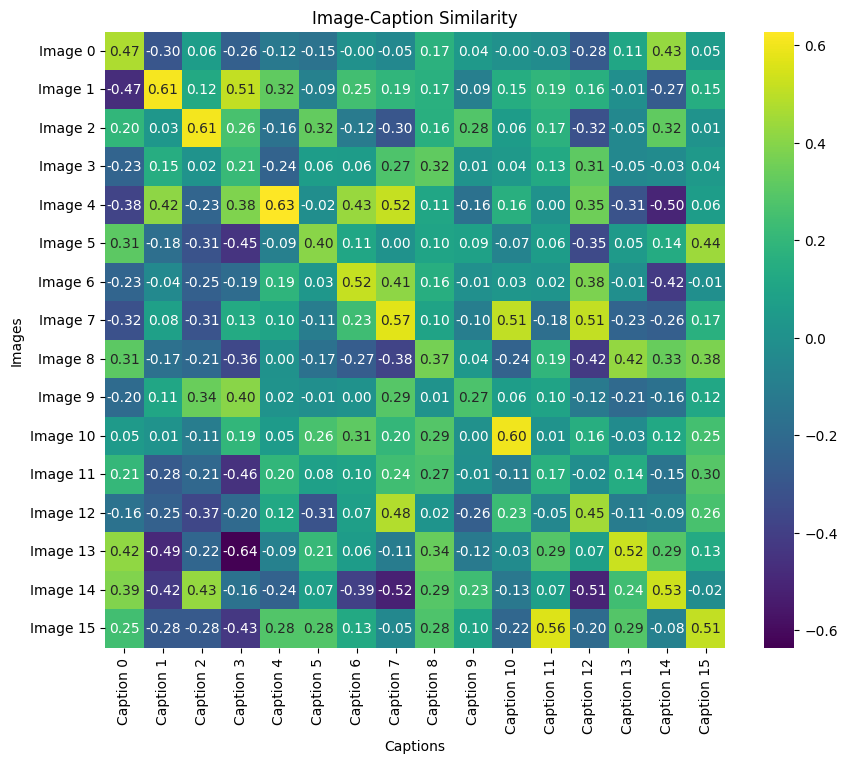

In [57]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    similarity_np,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    xticklabels=[
        f"Caption {i}"
        for i in range(len(captions))
    ],
    yticklabels=[
        f"Image {i}"
        for i in range(len(images))
    ]
)

plt.xlabel("Captions")
plt.ylabel("Images")
plt.title("Image-Caption Similarity")
plt.show()



In [70]:
image_encoder.save_weights(
    "image_encoder.weights.h5"
)

text_encoder.save_weights(
    "text_encoder.weights.h5"
)
